In [1]:
import numpy as np
from evaluation.samplers import random_VMF
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from notebooks.circle_plot_utils import (
    get_vectors_by_angle,
    draw_circle,
    draw_dencity,
    z_power_dencity,
    z_vonMises_dencity,
)

%load_ext autoreload
%autoreload 2

$$
p(\mathbf{z}|c) = p_{\text{power}}(\mathbf{z}|\boldsymbol{\mu}_c,\kappa) = \frac{\Gamma(\alpha + \beta)}{2^{\alpha + \beta}\pi^{\beta}\Gamma(\alpha)}\left(1 +\boldsymbol{\mu}^T_{c}\mathbf{z}\right)^{\kappa}
$$
$$
\alpha = \frac{d-1}{2} + \kappa,\quad \beta = \frac{d - 1}{2}
$$
$$
p(\mathbf{z}|\mathbf{x}) = p_{\text{power}}(\mathbf{z}|\boldsymbol{\mu}_{\mathbf{x}},\kappa_{\mathbf{x}})
$$
With d=2:

### Create toy data

In [2]:
d = 2  # sphere dimention
K = 3  # num_gallery_classes
M = 20  # support of oog classes
beta = 0.5  # oog class probability
kappa_gallery = 30  # concetration of gallery classes
num_samples = 20000  # number of MC samples
R = 1  # radius of the circle
probe_z_distribution = "vMF"  # distribution of p(z|x)
scale = 0.5

fontsize = 20
linewidth = 3
dot_size = 80

In [3]:
class_center_angles = np.array([0, np.pi / 6, np.pi / 4])
# class_center_angles = np.array([0, 2*np.pi / 3, 4*np.pi / 3])
class_z_kappa = np.array([kappa_gallery] * K)

probe_center_angles = np.array([np.pi / 2, -np.pi / 4, np.pi])
probe_z_kappa = np.array([10, 5, 0.01])
colors = ["tab:green"] * K + ["tab:blue"] * len(probe_z_kappa)
distribution_types = ["power"] * K + [probe_z_distribution] * len(probe_z_kappa)

In [4]:
def compute_p_z(zs, class_center_angles, class_z_kappa):
    """
    compute probability p(z)

    z: set of N z vectors Nx2
    """
    mu_c = get_vectors_by_angle(class_center_angles)
    p_zs = []
    for z in zs:
        p_z = beta / (2 * np.pi * R) + ((1 - beta) / K) * np.sum(
            [z_power_dencity(z, mu, kappa) for mu, kappa in zip(mu_c, class_z_kappa)]
        )
        p_zs.append(p_z)
    return np.array(p_zs)


def draw_oog_dencity(ax, angle, kappa, class_center_angles, class_z_kappa, scale):
    draw_dencity_angles = np.linspace(-np.pi, np.pi, 300)
    zs = get_vectors_by_angle(draw_dencity_angles)
    mu = get_vectors_by_angle([angle])[0]
    vMF_dencities = z_vonMises_dencity(zs, mu, kappa)
    p_z = compute_p_z(zs, class_center_angles, class_z_kappa)
    dencities = beta / (2 * np.pi * R) * vMF_dencities / p_z
    v = zs.T * (1 + dencities * scale)
    ax.plot(v[0], v[1], c="tab:red", linewidth=1)
    return dencities

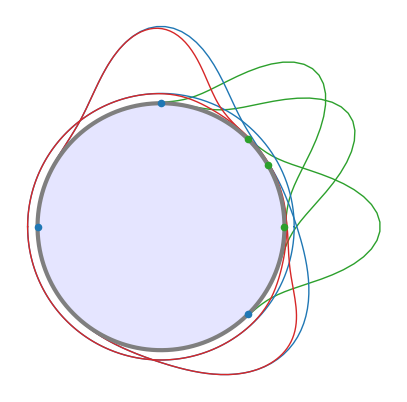

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax, linewidth)

for color, distribution_type, angle, kappa in zip(
    colors,
    distribution_types,
    np.concatenate([class_center_angles, probe_center_angles]),
    np.concatenate([class_z_kappa, probe_z_kappa]),
):
    draw_dencity(
        angle,
        kappa,
        ax,
        linewidth=1,
        color=color,
        range=np.pi,
        scale=scale,
        draw_center=True,
        dot_size=20,
        type=distribution_type,
    )
p_c_x_oog = []
for angle, kappa in zip(probe_center_angles, probe_z_kappa):
    dencities = draw_oog_dencity(
        ax, angle, kappa, class_center_angles, class_z_kappa, scale
    )
    p_c_x_oog.append(dencities)
p_c_x_oog = np.array(p_c_x_oog)
fig.gca().set_aspect("equal")
fig.show()

### Compute posterior $p(c|\textbf{x})$

1. $p(c|\textbf{x}),\, c\in (3,4]$  
see red curves above
2. $p(c|\textbf{x}),\, c\in \{1, 2, 3\}$  

In [6]:
assert probe_z_distribution == "vMF"
probe_z_samples = []
for angle, kappa in zip(probe_center_angles, probe_z_kappa):
    probe_z_samples.append(
        random_VMF(get_vectors_by_angle([angle])[0], kappa=[kappa], size=num_samples)
    )
probe_z_samples = np.concatenate(probe_z_samples, axis=0)

In [7]:
# compute gallery probabilities for each sample
mu_c = get_vectors_by_angle(class_center_angles)
p_c_x = []
for zs in probe_z_samples:
    p_z_c = np.zeros((zs.shape[0], K))
    # compute p_z_c
    for i, z in enumerate(zs):
        p_z_c[i] = np.array(
            [z_power_dencity(z, mu, kappa) for mu, kappa in zip(mu_c, class_z_kappa)]
        )
    p_z = beta / (2 * np.pi * R) + ((1 - beta) / K) * np.sum(p_z_c, axis=1)
    p_c_x.append(np.mean(((1 - beta) / K) * p_z_c / p_z[:, np.newaxis], axis=0))
p_c_x = np.array(p_c_x)

In [8]:
# p(c\in(3,4]|x) via integration
x = np.linspace(-np.pi, np.pi, 300)
np.sum(p_c_x_oog[0] * (2 * np.pi * R)) * (R * (x[1] - x[0]) / (2 * np.pi * R))

0.8443399628872511

Test if we could compute $\int_{3}^4 p(c|\textbf{x})dc$ using sampling: $\approx \beta \frac{1}{M}\sum_{i=1}^M \frac{1}{p(z_i)},\,z_i\sim p(z|x)$  
We can sample this way:

In [9]:
# p(c\in(3,4]|x) via integration sampling
test_pz = compute_p_z(probe_z_samples[0], class_center_angles, class_z_kappa)
beta * np.mean(1 / test_pz) / (2 * np.pi * R)

0.8458572630681713

In [10]:
np.sum(p_c_x[0]) + np.sum(p_c_x_oog[0] * (2 * np.pi * R)) * (
    R * (x[1] - x[0]) / (2 * np.pi * R)
)

0.9984826998190796

In [11]:
p_c_x

array([[0.00041074, 0.02139091, 0.13234109],
       [0.18178091, 0.0157967 , 0.00455241],
       [0.08533989, 0.05858454, 0.07475245]])

### Compute KL divergence $D_{KL}(p(c|\textbf{x})||p(c))$

In [12]:
kl_1 = np.sum(p_c_x * np.log(p_c_x / ((1 - beta) / K)), axis=1)
kl_1

array([-0.07690259, -0.03783059, -0.17831173])

In [13]:
kl_2 = []
p_z = compute_p_z(probe_z_samples[0], class_center_angles, class_z_kappa)
for probe_z_samp, angle, kappa in zip(
    probe_z_samples, probe_center_angles, probe_z_kappa
):
    p1 = z_vonMises_dencity(probe_z_samp, get_vectors_by_angle([angle])[0], kappa)
    kl_2.append((beta / (2 * np.pi * R)) * np.mean((1 / p_z) * np.log(p1 / p_z)))
kl_2 = np.array(kl_2)
kl_2

array([1.87531378, 1.466793  , 0.48350811])

In [14]:
kl_1 + kl_2

array([1.79841119, 1.42896241, 0.30519638])